In [1]:
import pandas as pd

train = pd.read_csv(r'C:\Users\sandu\Downloads\Data Set For Task\Churn Prdiction Data\churn-bigml-80.csv')
test = pd.read_csv(r'C:\Users\sandu\Downloads\Data Set For Task\Churn Prdiction Data\churn-bigml-20.csv')

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)
print("\nColumns:")
print(train.columns.tolist())
print("\nFirst 5 rows:")
print(train.head())

Training set shape: (2666, 20)
Testing set shape: (667, 20)

Columns:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

First 5 rows:
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                    

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [4]:
train = pd.read_csv(r'C:\Users\sandu\Downloads\Data Set For Task\Churn Prdiction Data\churn-bigml-80.csv')
test = pd.read_csv(r'C:\Users\sandu\Downloads\Data Set For Task\Churn Prdiction Data\churn-bigml-20.csv')

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)
print("\nMissing values in training set:")
print(train.isnull().sum().sum())

Training set shape: (2666, 20)
Testing set shape: (667, 20)

Missing values in training set:
0


In [5]:
# Combine train and test for preprocessing
combined = pd.concat([train, test], axis=0)

# Encode categorical columns (text → numbers)
le = LabelEncoder()
categorical_cols = ['State', 'International plan', 'Voice mail plan']

for col in categorical_cols:
    combined[col] = le.fit_transform(combined[col])

# Convert Churn True/False to 1/0
combined['Churn'] = combined['Churn'].astype(int)

# Split back into train and test
train = combined.iloc[:2666]
test = combined.iloc[2666:]

print("Preprocessing done!")
print(train.head())

Preprocessing done!
   State  Account length  Area code  International plan  Voice mail plan  \
0     16             128        415                   0                1   
1     35             107        415                   0                1   
2     31             137        415                   0                0   
3     35              84        408                   1                0   
4     36              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99      

In [6]:
# X = all columns except Churn
# y = Churn column only
X_train = train.drop(columns=['Churn'])
y_train = train['Churn']

X_test = test.drop(columns=['Churn'])
y_test = test['Churn']

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features shape:", X_train.shape)
print("Target shape:", y_train.shape)

Features shape: (2666, 19)
Target shape: (2666,)


In [7]:
# Model 1 - Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Model 2 - Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Model 3 - Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [8]:
models = {
    'Decision Tree': dt_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model
}

print("Model Performance Comparison:")
print("="*60)

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4)
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")

results_df = pd.DataFrame(results)

Model Performance Comparison:

Decision Tree:
  Accuracy  : 0.9175
  Precision : 0.7041
  Recall    : 0.7263
  F1 Score  : 0.7150

Logistic Regression:
  Accuracy  : 0.8531
  Precision : 0.4595
  Recall    : 0.1789
  F1 Score  : 0.2576

Random Forest:
  Accuracy  : 0.9460
  Precision : 0.9538
  Recall    : 0.6526
  F1 Score  : 0.7750


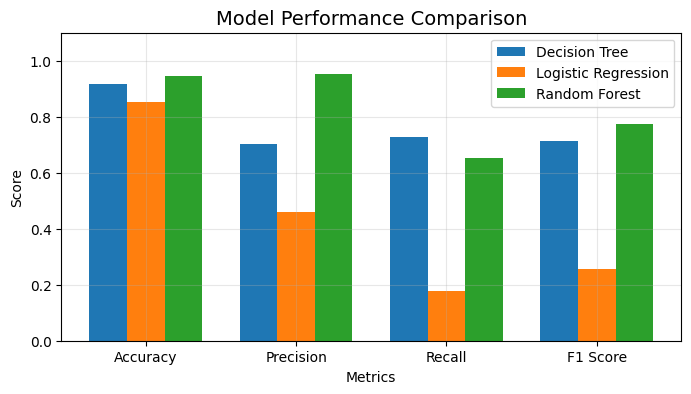

Model comparison chart saved!


In [12]:
plt.figure(figsize=(8, 4))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = range(len(metrics))
width = 0.25

for i, (_, row) in enumerate(results_df.iterrows()):
    plt.bar([p + width*i for p in x], 
            [row[m] for m in metrics],
            width=width,
            label=row['Model'])

plt.title('Model Performance Comparison', fontsize=14)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.xticks([p + width for p in x], metrics)
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 3\model_comparison.png')
plt.show()
print("Model comparison chart saved!")

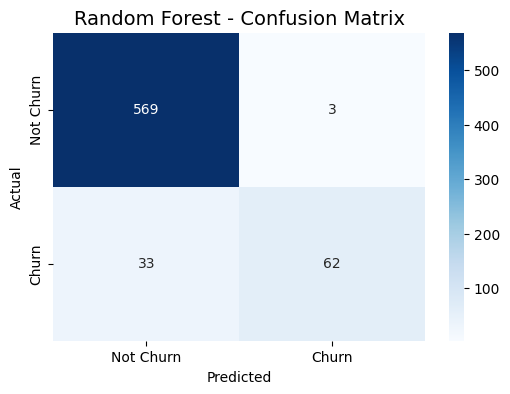

Confusion matrix saved!


In [14]:
# Random Forest is usually best - let's plot its confusion matrix
y_pred_rf = rf_model.predict(X_test_scaled)

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Random Forest - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 3\confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

In [15]:
# Fine tune Random Forest using Grid Search
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid,
                           cv=3,
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best Accuracy: 0.9509


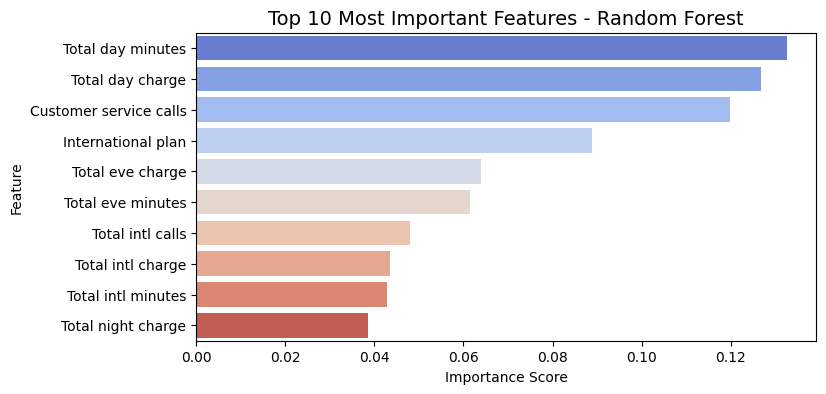

Feature importance chart saved!


In [18]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importance,
            x='Importance',
            y='Feature',
            hue='Feature',
            palette='coolwarm',
            legend=False)
plt.title('Top 10 Most Important Features - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 3\feature_importance.png')
plt.show()
print("Feature importance chart saved!")

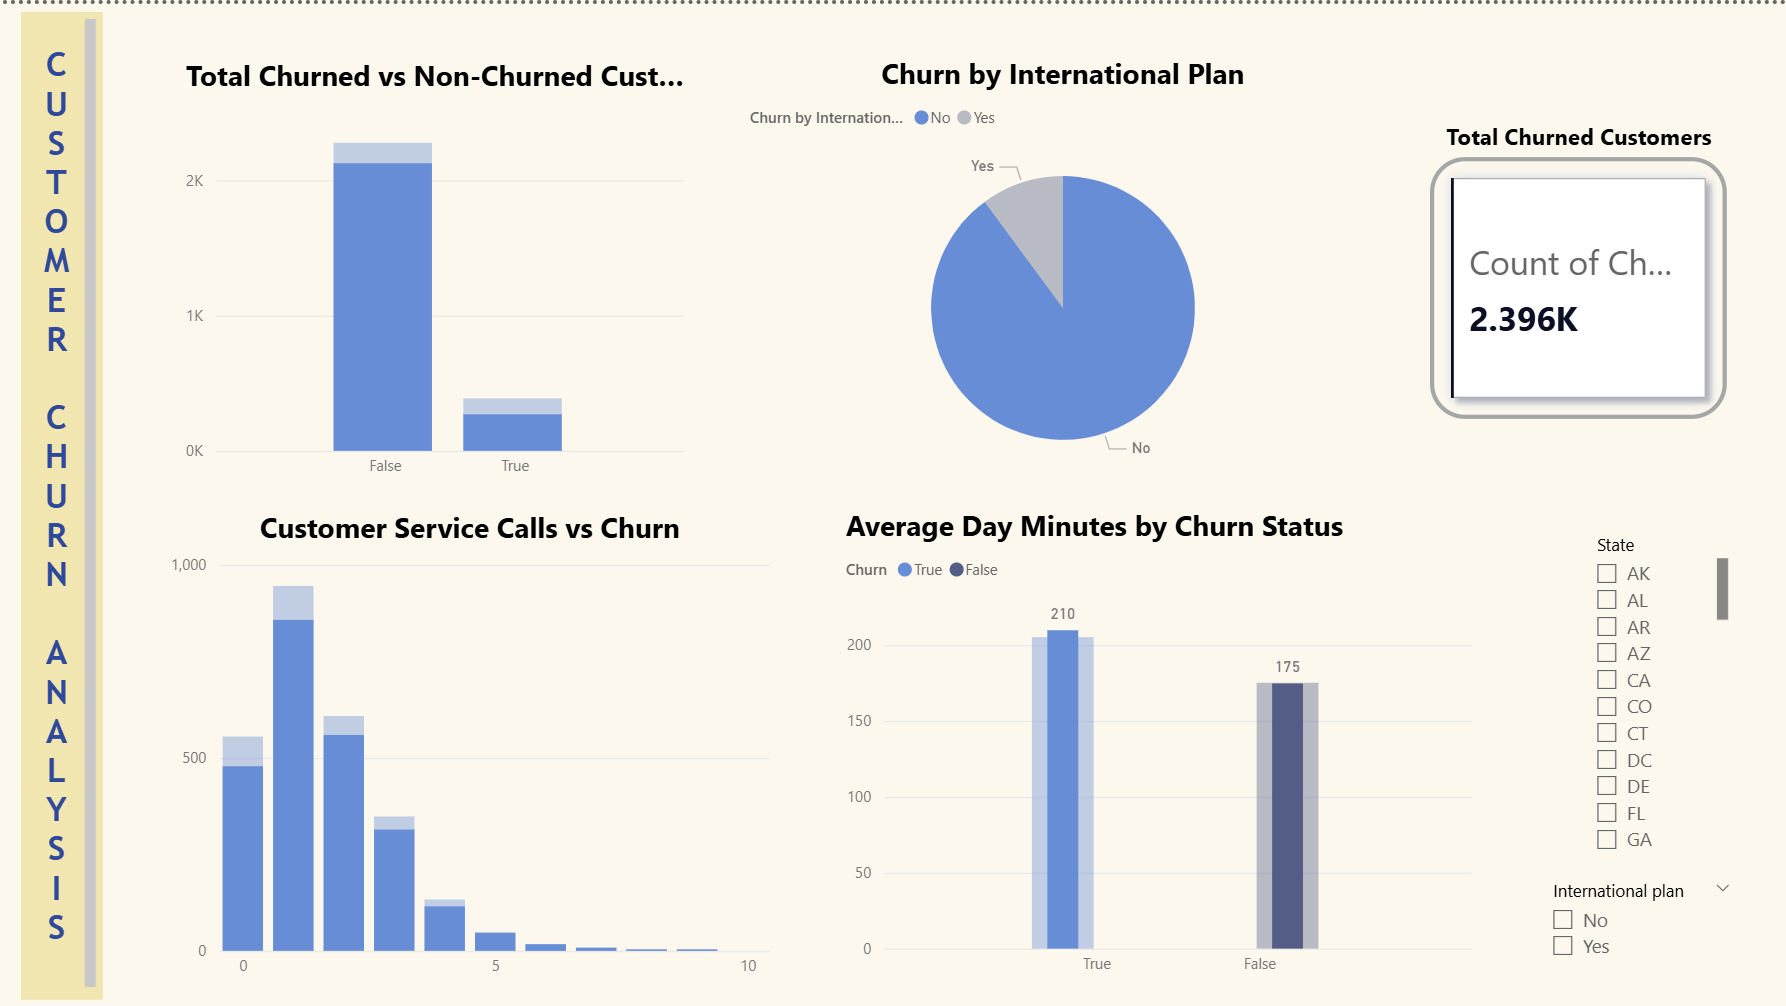

In [2]:
#show Task 2 Dashboard 

from IPython.display import Image

# Show your dashboard screenshot inside notebook!
Image(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 3\Customer Churn Dashboard.png')